In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.ESINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])

x0 = default_x0['lotka_volterra']

In [3]:
default_params['lotka_volterra']

(1.1, 0.4, 0.4, 0.1)

In [4]:
# n = 5000

# indices = np.random.choice(n, n, replace=True)

# print(f'fraction of data used: {len(set(indices)) / n}')

In [7]:
# evaluate how models perform with different time steps

t_span = (0, 50)

threshold = 0.05
noise_level = 0.01 # set a fixed noise level for all tests

# dts = np.linspace(0.01, 1, 10)
dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

t_evals = []
x_trains = []
models = []
x_preds = []
for dt in tqdm(dts):
    # generate evaluation time points
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    t_evals.append(t_eval)

    # generate training data
    x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)
    x_trains.append(x_train)
    
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    # generate the derivative of the noisy data
    x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)
    
    # create and fit a SINDy model
    model = ESINDyModel(n_state_vars=2, threshold=threshold, inclusion_threshold=0.6, poly_order=5)
    model.fit(x_train_noisy, x_dot_approx, 100)
    models.append(model)
    
    x_pred = generate_model_prediction(model, x0, t_eval)
    x_preds.append(x_pred)

    # print the model if it failed to generate a prediction
    if x_pred is None:
        print(f"failed to generate model prediction for model trained with dt={dt}")


# print the models
for i in range(len(dts)):
    print(f"dt: {dts[i]}")
    models[i].print()
    print()

100%|██████████| 7/7 [00:07<00:00,  1.04s/it]

dt: 0.01
x0' = + 1.09405 x0 + -0.39963 x0 x1 
x1' = + -0.39780 x1 + 0.10006 x0 x1 

dt: 0.02
x0' = + 1.09924 x0 + -0.39998 x0 x1 
x1' = + -0.39411 x1 + 0.09916 x0 x1 

dt: 0.05
x0' = + 1.09473 x0 + -0.39851 x0 x1 
x1' = + -0.39812 x1 + 0.09926 x0 x1 

dt: 0.1
x0' = + 1.08476 x0 + -0.39390 x0 x1 
x1' = + -0.39729 x1 + 0.09861 x0 x1 

dt: 0.2
x0' = + 1.05221 x0 + -0.38254 x0 x1 
x1' = + -0.39159 x1 + 0.09662 x0 x1 

dt: 0.5
x0' = + 0.03846 1 + 0.83696 x0 + -0.11627 x1 + -0.29704 x0 x1 
x1' = + -0.33984 x1 + 0.07899 x0 x1 

dt: 1
x0' = + 0.72278 x0 + -0.17262 x0 x1 
x1' = + 0.18144 x0 + -0.15175 x1 



In [8]:
for i in range(len(dts)):
    if x_preds[i] is None:
        print(f"dt: {dts[i]:.6f}, failed to generate model prediction")
        continue
    rte = relative_trajectory_error(x_trains[i], x_preds[i])
    print(f"dt: {dts[i]:.6f}, relative trajectory error: {rte:.6f}")

dt: 0.010000, relative trajectory error: 0.248633
dt: 0.020000, relative trajectory error: 0.321558
dt: 0.050000, relative trajectory error: 0.140669
dt: 0.100000, relative trajectory error: 0.200427
dt: 0.200000, relative trajectory error: 0.630122
dt: 0.500000, relative trajectory error: 149434872364642.656250
dt: 1.000000, relative trajectory error: 0.905695


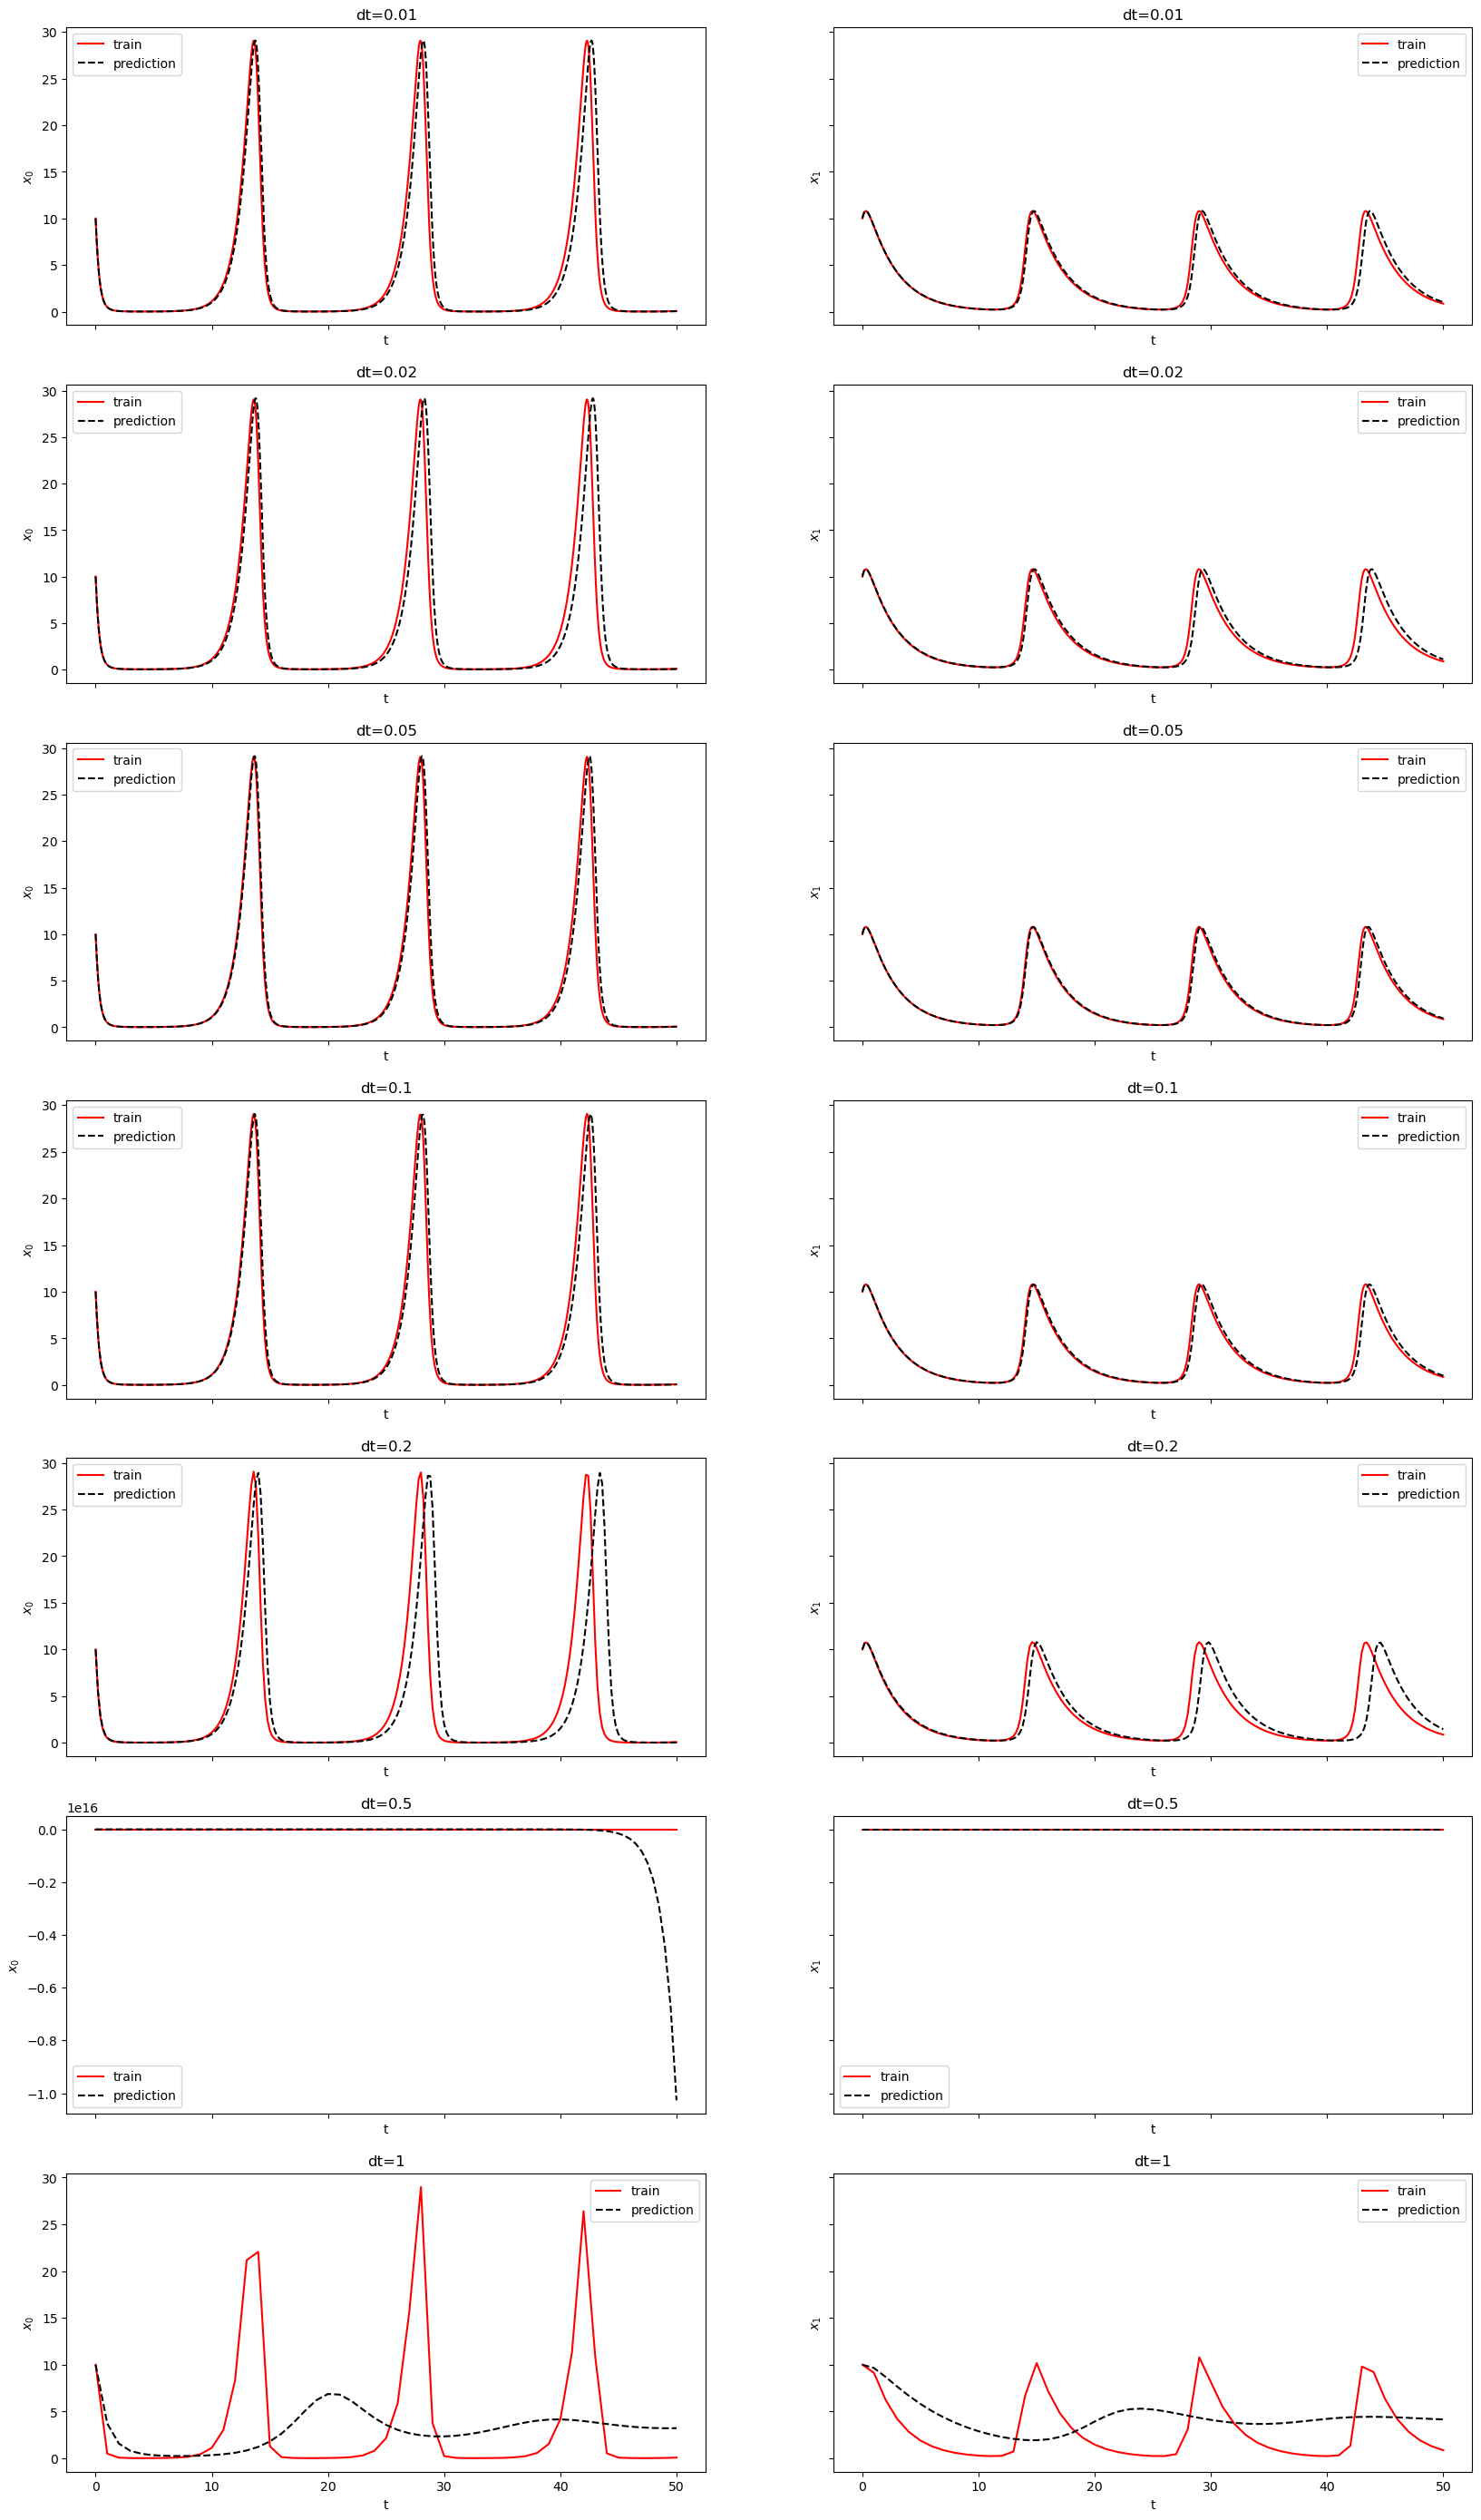

In [9]:
# plot the results

n_dts = len(dts)
n_svs = len(x0)

fig, axs = plt.subplots(n_dts, n_svs, figsize=(10*n_svs, 5*n_dts), sharex='col', sharey='row')

for dt_idx in range(n_dts):
    # skip if the model prediction failed
    if x_preds[dt_idx] is None:
        continue

    for sv_idx in range(n_svs):
        # plot the sv_idx'th training state variable
        axs[dt_idx, sv_idx].plot(t_evals[dt_idx], x_trains[dt_idx][sv_idx], "r", label="train")
        
        # plot the sv_idx'th state variable model prediction
        axs[dt_idx, sv_idx].plot(t_evals[dt_idx], x_preds[dt_idx][sv_idx], "k--", label="prediction")

        # set the title and labels
        axs[dt_idx, sv_idx].set_title(f"dt={dts[dt_idx]}")
        axs[dt_idx, sv_idx].set_xlabel("t")
        axs[dt_idx, sv_idx].set_ylabel(f"$x_{sv_idx}$")
        axs[dt_idx, sv_idx].legend()